In [166]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from phd_helpers.experiments import get_stress_strain, get_instron_data

# Vero

Text(0, 0.5, 'Force (kN)')

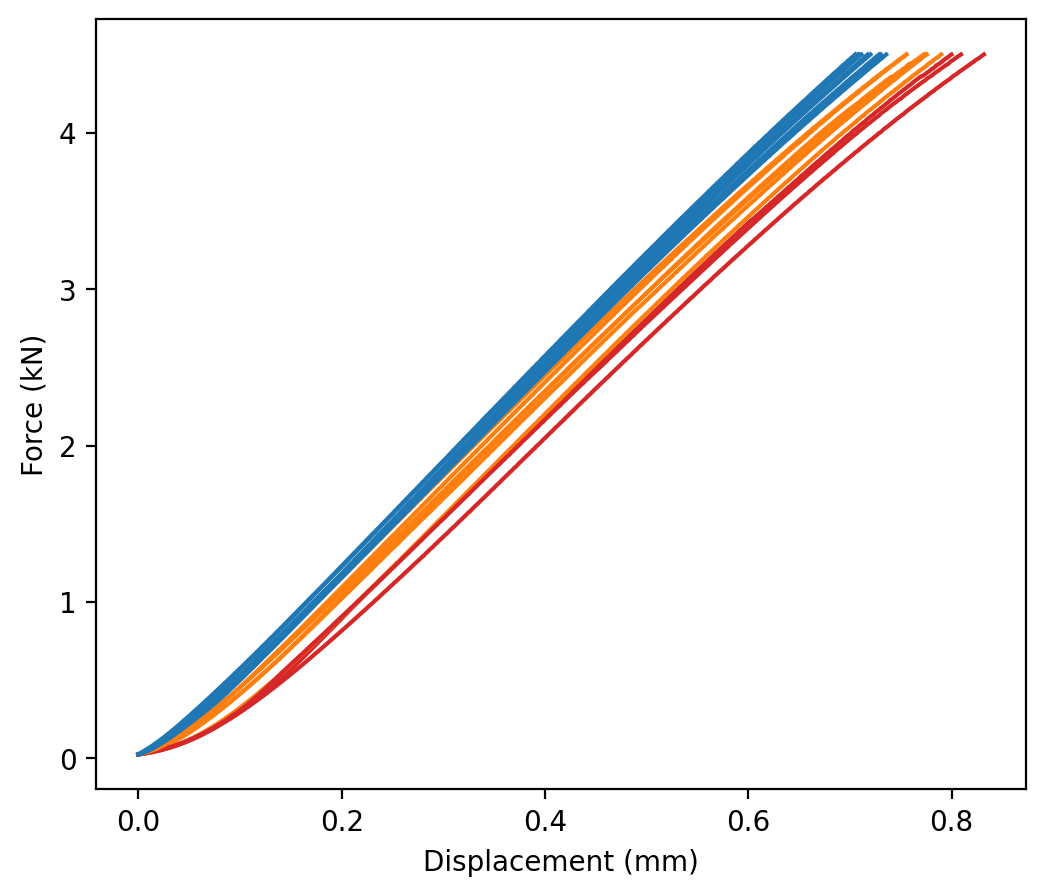

In [173]:
# Original test #

orig_path = Path('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/Experiments/Cylinders3D/VeroCylinders/20251217')
glob = '**/*[HV]?_[123].csv'

nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), dpi=200)

orient_idx = -8
c_orig = {'V':'C0', 'H': 'C1', 'H1': 'C3'}
F0 = 25*1e-3
for path in orig_path.glob(glob):
    data_raw = get_instron_data(path, False)
    data = data_raw[data_raw['force'] >= F0] # get data after initial load
    data['displacement'] -= data['displacement'].min() # reset displacement

    orient = 'H1' if path.name[orient_idx] == 'H' and path.name[-5] == '1' else path.name[orient_idx]
    ax.plot(data['displacement'], data['force'], c=c_orig[orient])


# New test #

new_path = Path('../../../LabData/materialsTesting/cylinders/vero/20260428')

c_new = {'V':'C4', 'H': 'C5'}
glob = '**/*.csv'
F0 = 25*1e-3
for path in new_path.glob(glob):
    data_raw = get_instron_data(path, False)
    data = data_raw[data_raw['force'] >= F0] # get data after initial load
    data['displacement'] -= data['displacement'].min() # reset displacement

    #orient = path.name[orient_idx]
    #ax.plot(data['displacement'], data['force'], c='C6')

ax.set_xlabel('Displacement (mm)')
ax.set_ylabel('Force (kN)')

# Final data

### Elastico

In [145]:
# get data

e50_path = Path('../../../LabData/materialsTesting/cylinders/elastico/20260427')

F0 = 0.5 # (N) initial seating load
dN = 10 # (mm) total displacement after preload applied

L0 = 20
A0 = np.pi*(5**2) # mm^2

orientations = ['Vertical', 'Horizontal']

e50 = []
for orient in orientations:
    glob = f'**/{orient[0]}.*/*.csv'
    for path in e50_path.glob(glob):
        sample_repeat = path.with_suffix('').name # e.g. 1_3 (sample 1 repeat 3)
        s, r = sample_repeat.split('_')

        data_raw = get_instron_data(path, False)
        data_raw['force'] *= 1e3 # convert from kN to N
        data = data_raw[data_raw['force'] >= F0] # get data after initial load
        data['displacement'] -= data['displacement'].min() # reset displacement
        data = data[data['displacement'] <= dN] # clip excess

        data['strain'] = data['displacement'] / L0
        data['stress'] = data['force'] / A0 # MPa

        data['orient'] = np.full(len(data), orient)
        data['sample'] = np.full(len(data), int(s))
        data['repeat'] = np.full(len(data), int(r))

        e50.append(data)
        
df = pd.concat(e50).sort_values(['orient', 'sample', 'repeat', 'time'], ascending=True).reset_index(drop=True)

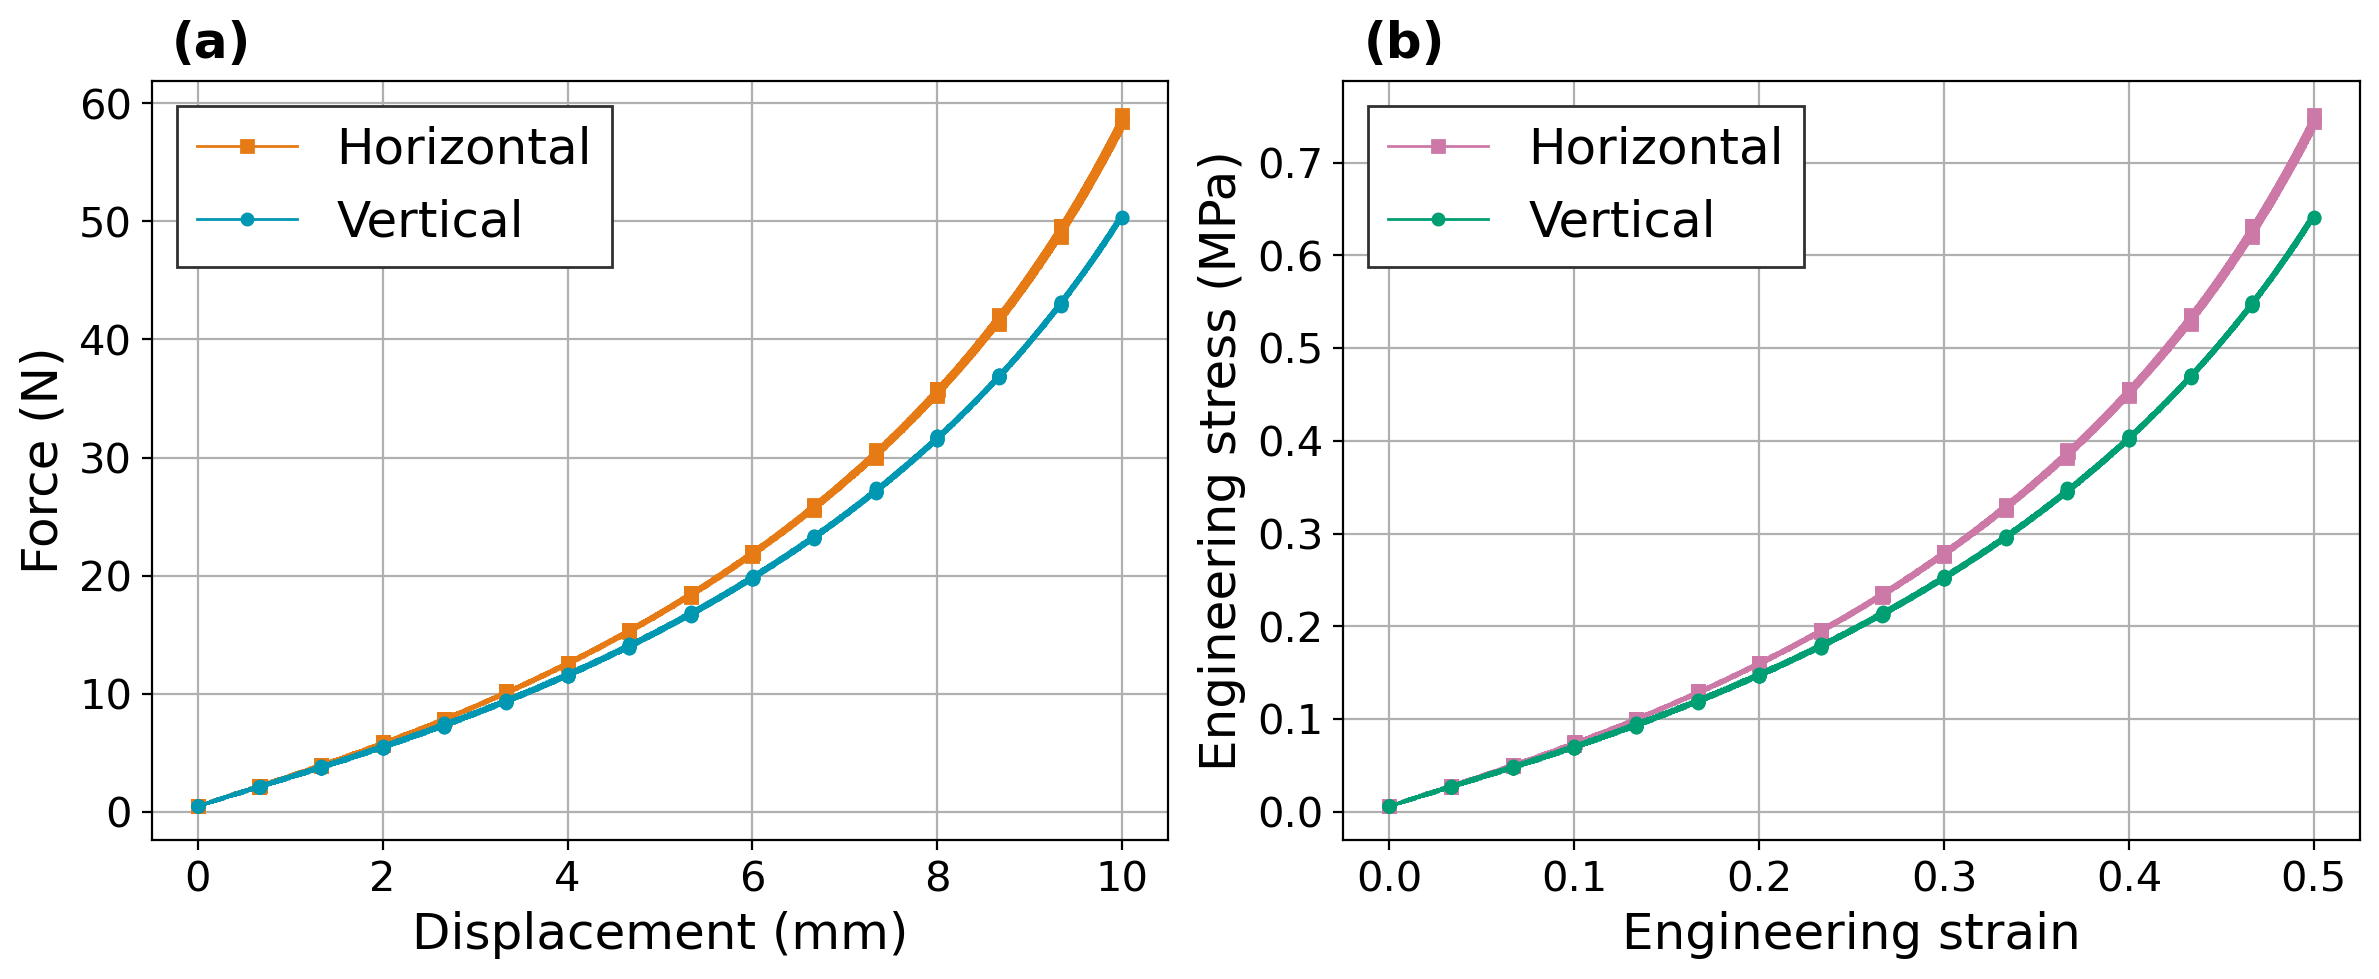

In [146]:
# plot data

colors = {
    "Vertical": {
        "force": "#0097b2",
        "stress": "#009e73",
    },
    "Horizontal": {
        "force": "#e67a14",
        "stress": "#cc79a7"
         #"#bfb200"
    }
}
markers = {
    "Vertical": "o",      # circle
    "Horizontal": "s",    # square
}

fs = 18

nrows, ncols = 1, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), dpi=200)

labelled = set()
for (orient, sample, repeat), g in df.groupby(["orient", "sample", "repeat"], sort=False):
    label = orient if orient not in labelled else None
    labelled.add(orient)

    ax[0].plot(
        g["displacement"], g["force"],
        c=colors[orient]["force"],
        marker=markers[orient],
        markersize=4,
        markevery=2000,
        linewidth=1,
        label=label
    )

    ax[1].plot(
        g["strain"], g["stress"],
        c=colors[orient]["stress"],
        marker=markers[orient],
        markersize=4,
        markevery=2000,
        linewidth=1,
        label=label
    )

ax[0].set_xlabel("Displacement (mm)", fontsize=fs)
ax[0].set_ylabel("Force (N)", fontsize=fs)
ax[1].set_xlabel("Engineering strain", fontsize=fs)
ax[1].set_ylabel("Engineering stress (MPa)", fontsize=fs)

for a in ax:
    leg = a.legend(frameon=True, fancybox=False, edgecolor="#303030", framealpha=1, fontsize=fs)
    leg.get_frame().set_linewidth(1.0)
    a.grid(True)
    a.tick_params(axis="both", labelsize=15)

# subplot labels
for i, label in enumerate(["(a)", "(b)"]):
    ax[i].text(
        0.02, 1.08, label,
        transform=ax[i].transAxes,
        fontsize=fs,
        fontweight="bold",
        va="top",
        ha="left"
    )

fig.tight_layout()
plt.savefig('figs/elastico-compression-curves.pdf', dpi=300, bbox_inches="tight")

In [154]:
# compute metrics

modulus_ranges = [(0.0, 0.20), (0.20, 0.40), (0.40, 0.50)]
target_strains = [0.20, 0.40, 0.50]


def interp_stress_at_strain(g, target_strain):
    """Interpolate stress at a given strain"""
    g = g.sort_values("strain")
    return np.interp(target_strain, g["strain"], g["stress"])


def secant_modulus_between(g, a, b):
    """Secant modulus between strains a and b"""
    stress_a = interp_stress_at_strain(g, a)
    stress_b = interp_stress_at_strain(g, b)
    return (stress_b - stress_a) / (b - a)

import pandas as pd

def mean_relative_difference(df):
    """mean % diff"""
    H = df[df['orient']=='Horizontal']['mean'].values
    V = df[df['orient']=='Vertical']['mean'].values
    return 100 * (H - V) / ((H+V) / 2)


# -------------------------------------------------------------------
# 1. Modulus between different strain ranges
# -------------------------------------------------------------------

curve_groups = ["orient", "sample", "repeat"]

modulus_rows = []

for (orient, sample, repeat), g in df.groupby(curve_groups):
    for a, b in modulus_ranges:
        modulus_rows.append({
            "orient": orient,
            "sample": sample,
            "repeat": repeat,
            "strain_range": f"{a:.2f}-{b:.2f}",
            "modulus": secant_modulus_between(g, a, b)
        })

modulus_df = pd.DataFrame(modulus_rows)

modulus_summary = (
    modulus_df
    .groupby(["orient", "strain_range"])["modulus"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

modulus_summary.round(3)

,orient,strain_range,mean,std,count
0,Horizontal,0.00-0.20,0.766,0.005,9
1,Horizontal,0.20-0.40,1.469,0.009,9
2,Horizontal,0.40-0.50,2.918,0.027,9
3,Vertical,0.00-0.20,0.703,0.005,9
4,Vertical,0.20-0.40,1.280,0.004,9
5,Vertical,0.40-0.50,2.396,0.011,9


In [155]:
mean_relative_difference(modulus_summary)

array([ 8.57005114, 13.74159479, 19.6486107 ])

In [95]:
# -------------------------------------------------------------------
# 2. Stress at given strain values
# -------------------------------------------------------------------

stress_rows = []
for (orient, sample, repeat), g in df.groupby(curve_groups):
    for eps in target_strains:
        stress_rows.append({
            "orient": orient,
            "sample": sample,
            "repeat": repeat,
            "strain": eps,
            "stress": interp_stress_at_strain(g, eps)
        })
stress_at_strain_df = pd.DataFrame(stress_rows)

stress_summary = (
    stress_at_strain_df
    .groupby(["orient", "strain"])["stress"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

stress_summary.round(3)

,orient,strain,mean,std,count
0,Horizontal,0.2,0.160,0.001,9
1,Horizontal,0.4,0.453,0.003,9
2,Horizontal,0.5,0.745,0.005,9
3,Vertical,0.2,0.147,0.001,9
4,Vertical,0.4,0.403,0.001,9
5,Vertical,0.5,0.643,0.002,9


In [156]:
mean_relative_difference(stress_summary)

array([ 8.21411917, 11.76273474, 14.7823443 ])

In [152]:
# -------------------------------------------------------------------
# 3. Stress at given strain values, grouped by repeat number
# -------------------------------------------------------------------

stress_by_repeat_summary = (
    stress_at_strain_df
    .groupby(["orient", "repeat", "strain"])["stress"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
stress_by_repeat_summary = stress_by_repeat_summary[(stress_by_repeat_summary['strain']==0.5)]
stress_by_repeat_summary.round(3)

,orient,repeat,strain,mean,std,count
2,Horizontal,1,0.5,0.740,0.005,3
5,Horizontal,2,0.5,0.747,0.003,3
8,Horizontal,3,0.5,0.749,0.004,3
11,Vertical,1,0.5,0.643,0.002,3
14,Vertical,2,0.5,0.643,0.003,3
17,Vertical,3,0.5,0.641,0.001,3


In [157]:
mean_relative_difference(stress_by_repeat_summary)

array([13.98772886, 14.90531729, 15.4503848 ])